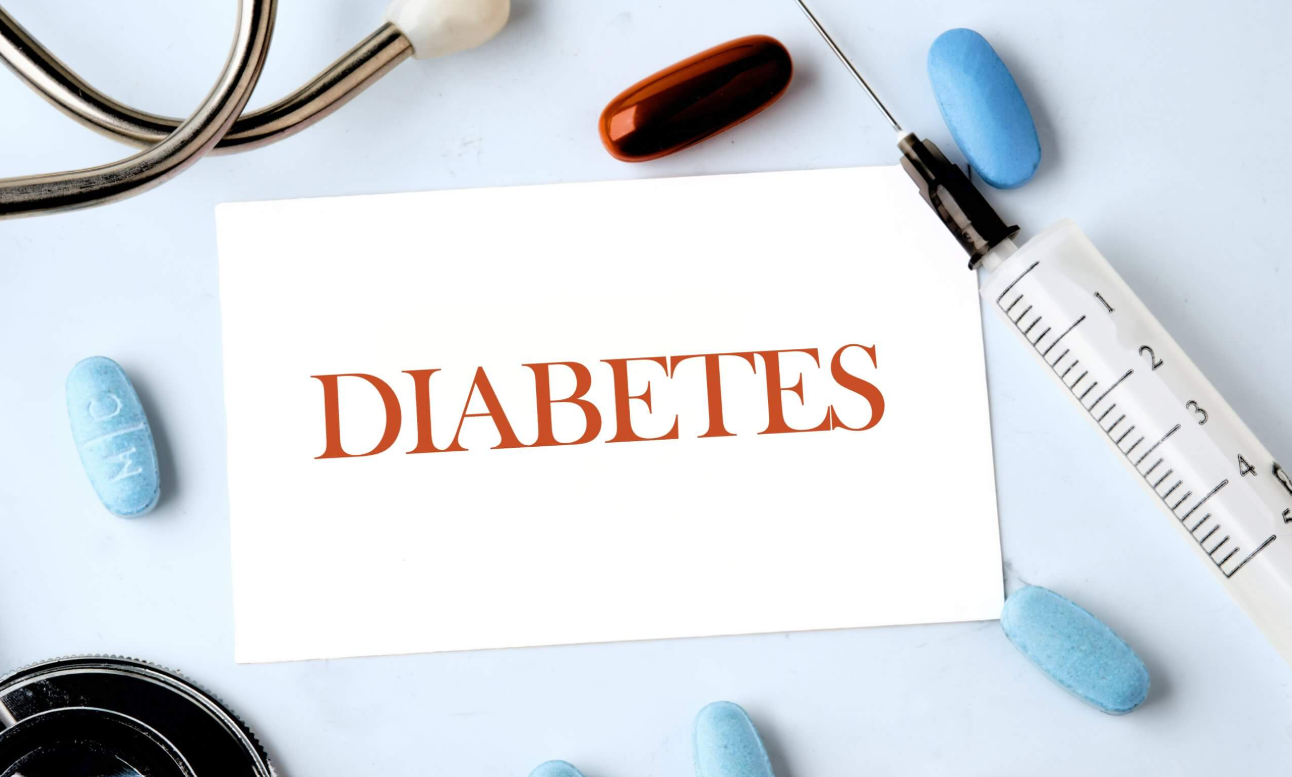

# Business Problem: 

The goal is to create a machine learning model that can accurately predict whether a person has diabetes based on their provided features. Prior to developing the model, it is crucial to carry out the necessary steps of data analysis and feature engineering to ensure the model is built on a strong foundation. This involves cleaning the data, handling missing values, transforming and selecting relevant features, and exploring the relationships between different variables to enhance the model's predictive power.

# Dataset Story:

The dataset is part of a larger dataset provided by the National Institutes of Diabetes, Digestive, and Kidney Diseases in the United States. It contains data collected from Pima Indian women aged 21 years and older who live in Phoenix, the 5th largest city in the state of Arizona, and is used for diabetes research.

The target variable is labeled as **"Outcome"** where a value of 1 indicates a positive result for diabetes, and a value of 0 indicates a negative result.

The features in the dataset are as follows:

**Pregnancies:** Number of pregnancies the individual has had

**Glucose:** 2-hour plasma glucose concentration in the oral glucose tolerance test

**Blood Pressure:** Blood pressure (in mm Hg)

**SkinThickness:** Thickness of the skinfold

**Insulin:** 2-hour serum insulin concentration (mu U/ml)

**DiabetesPedigreeFunction:** Diabetes pedigree function, indicating family history of diabetes

**BMI:** Body mass index

**Age:** Age in years

**Outcome:** Whether the individual has diabetes (1) or not (0)

# Road Map

1. Import Required Libaries
2. Adjusting Row Column Settings
3. Loading The Dataset
4. Exploratory Data Analysis
5. Capturing / Detecting Numeric and Categorical Variables
6. Analysis of Categorical Variables
7. Analysis of Numerical Variables
8. Analysis of Categorical Variables by Target
9. Analysis of Numeric Variables by Target
10. correlation Analysis
11. The Relationship Between Variables
12. Outlier Analysis
13. Missing Value Analysis
14. Feature Extraction
15. Encoding
16. Standardization Process
17. Creating Model
18. Feature Importance
19. Hyperparameter Optimization
20. Final Model

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/diabetes-prediction-dataset/diabetes.csv


# 1. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import itertools
import plotly.graph_objects as go
import time

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.metrics import classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV, ShuffleSplit, StratifiedKFold
from sklearn.model_selection import GridSearchCV, cross_validate, RandomizedSearchCV, validation_curve
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_graphviz, export_text
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.simplefilter(action="ignore")

import warnings
warnings.simplefilter(action="ignore")

# 2. Adjusting Row Column Settings

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# 3. Loading The Dataset

In [4]:
df = pd.read_csv("/kaggle/input/diabetes-prediction-dataset/diabetes.csv")

# 4. Exploratory Data Analysis

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


In [6]:
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(head))
    print("##################### Tail #####################")
    print(dataframe.tail(head))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

check_df(df)

##################### Shape #####################
(768, 9)
##################### Types #####################
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
##################### Head #####################
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0            6      148             72             35        0 33.600   
1            1       85             66             29        0 26.600   
2            8      183             64              0        0 23.300   
3            1       89             66             23       94 28.100   
4            0      137             40             35      168 43.100   

   DiabetesPedigreeFunction  Age  Outcome  
0                    

# 5. Capturing / Detecting Numeric and Categorical Variables

In [7]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"] 

    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]

    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]

    cat_cols = cat_cols + num_but_cat

    cat_cols = [col for col in cat_cols if col not in cat_but_car] 

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"] 

    num_cols = [col for col in num_cols if col not in num_but_cat] 
    
    print(f"Observations: {dataframe.shape[0]}") 
    print(f"Variables: {dataframe.shape[1]}") 
    print(f'cat_cols: {len(cat_cols)}') 
    print(f'num_cols: {len(num_cols)}') 
    print(f'cat_but_car: {len(cat_but_car)}') 
    print(f'num_but_cat: {len(num_but_cat)}') 


    return cat_cols, num_cols, cat_but_car, num_but_cat

In [8]:
cat_cols, num_cols, cat_but_car,  num_but_cat = grab_col_names(df)

Observations: 768
Variables: 9
cat_cols: 1
num_cols: 8
cat_but_car: 0
num_but_cat: 1


In [9]:
cat_cols

['Outcome']

In [10]:
num_cols

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

# 6. Analysis of Categorical Variables

In [11]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show(block=True)

         Outcome  Ratio
Outcome                
0            500 65.104
1            268 34.896
##########################################


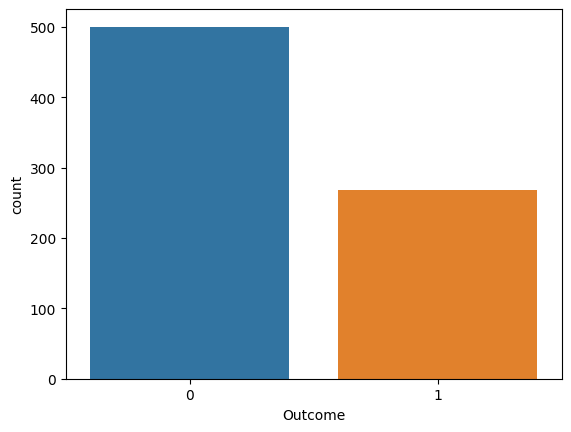

In [12]:
cat_summary(df, "Outcome", plot=True)

# 7. Analysis of Numerical Variables

In [13]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

count   768.000
mean      3.845
std       3.370
min       0.000
5%        0.000
10%       0.000
20%       1.000
30%       1.000
40%       2.000
50%       3.000
60%       4.000
70%       5.000
80%       7.000
90%       9.000
95%      10.000
99%      13.000
max      17.000
Name: Pregnancies, dtype: float64


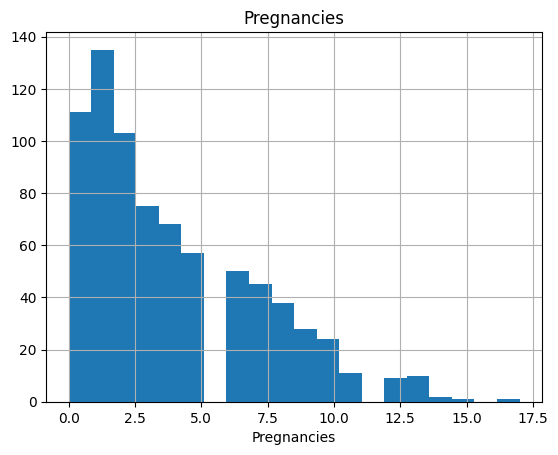

count   768.000
mean    120.895
std      31.973
min       0.000
5%       79.000
10%      85.000
20%      95.000
30%     102.000
40%     109.000
50%     117.000
60%     125.000
70%     134.000
80%     147.000
90%     167.000
95%     181.000
99%     196.000
max     199.000
Name: Glucose, dtype: float64


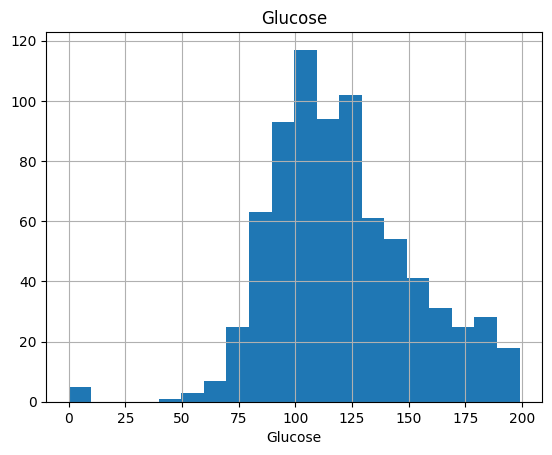

count   768.000
mean     69.105
std      19.356
min       0.000
5%       38.700
10%      54.000
20%      60.000
30%      64.000
40%      68.000
50%      72.000
60%      74.000
70%      78.000
80%      82.000
90%      88.000
95%      90.000
99%     106.000
max     122.000
Name: BloodPressure, dtype: float64


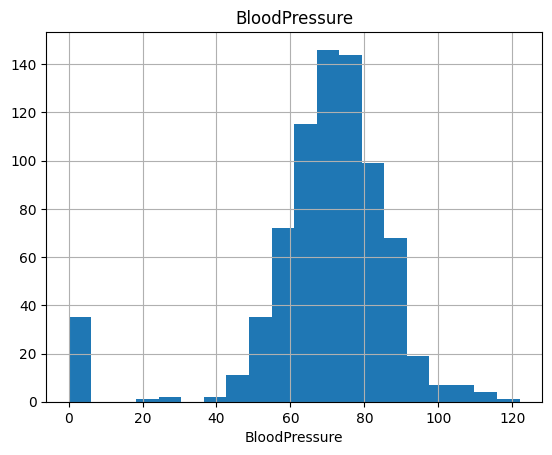

count   768.000
mean     20.536
std      15.952
min       0.000
5%        0.000
10%       0.000
20%       0.000
30%       8.200
40%      18.000
50%      23.000
60%      27.000
70%      31.000
80%      35.000
90%      40.000
95%      44.000
99%      51.330
max      99.000
Name: SkinThickness, dtype: float64


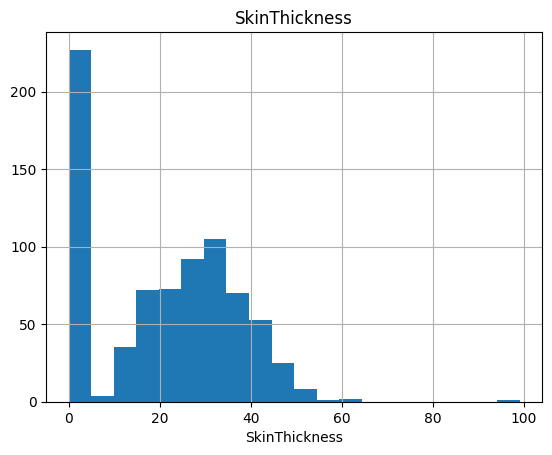

count   768.000
mean     79.799
std     115.244
min       0.000
5%        0.000
10%       0.000
20%       0.000
30%       0.000
40%       0.000
50%      30.500
60%      72.200
70%     106.000
80%     150.000
90%     210.000
95%     293.000
99%     519.900
max     846.000
Name: Insulin, dtype: float64


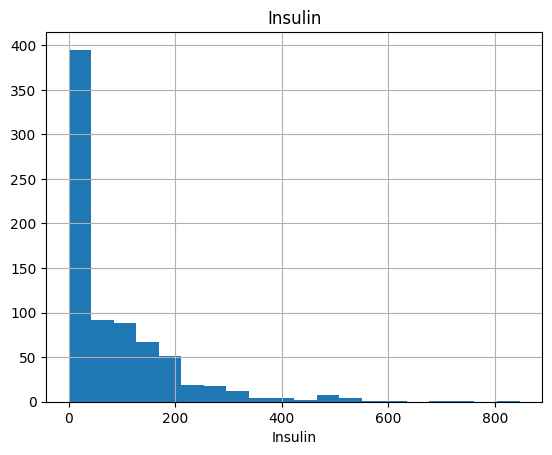

count   768.000
mean     31.993
std       7.884
min       0.000
5%       21.800
10%      23.600
20%      25.900
30%      28.200
40%      30.100
50%      32.000
60%      33.700
70%      35.490
80%      37.800
90%      41.500
95%      44.395
99%      50.759
max      67.100
Name: BMI, dtype: float64


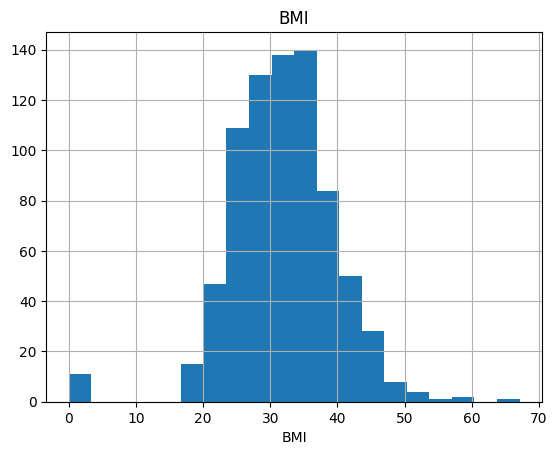

count   768.000
mean      0.472
std       0.331
min       0.078
5%        0.140
10%       0.165
20%       0.219
30%       0.259
40%       0.303
50%       0.372
60%       0.454
70%       0.564
80%       0.687
90%       0.879
95%       1.133
99%       1.698
max       2.420
Name: DiabetesPedigreeFunction, dtype: float64


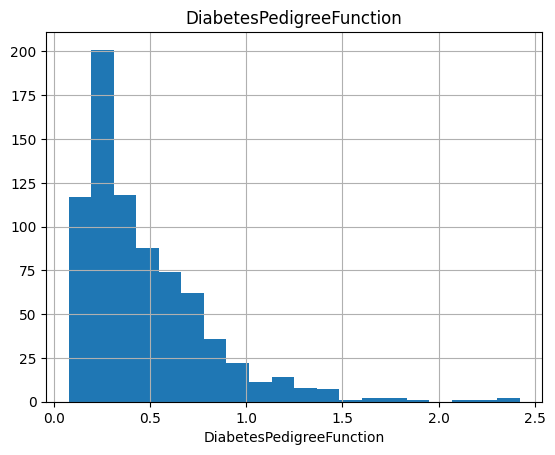

count   768.000
mean     33.241
std      11.760
min      21.000
5%       21.000
10%      22.000
20%      23.000
30%      25.000
40%      27.000
50%      29.000
60%      33.000
70%      38.000
80%      42.600
90%      51.000
95%      58.000
99%      67.000
max      81.000
Name: Age, dtype: float64


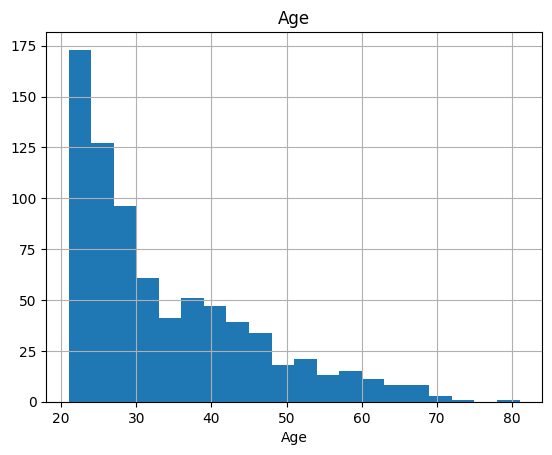

In [14]:
for col in num_cols:
    num_summary(df, col, plot=True)

# 8. Analysis of Categorical Variables by Target

In [15]:
def target_summary_with_cat(dataframe, target, categorical_col, plot=False):
    print(pd.DataFrame({'TARGET_MEAN': dataframe.groupby(categorical_col)[target].mean()}), end='\n\n\n')
    if plot:
        sns.barplot(x=categorical_col, y=target, data=dataframe)
        plt.show(block=True)

         TARGET_MEAN
Outcome             
0              0.000
1              1.000




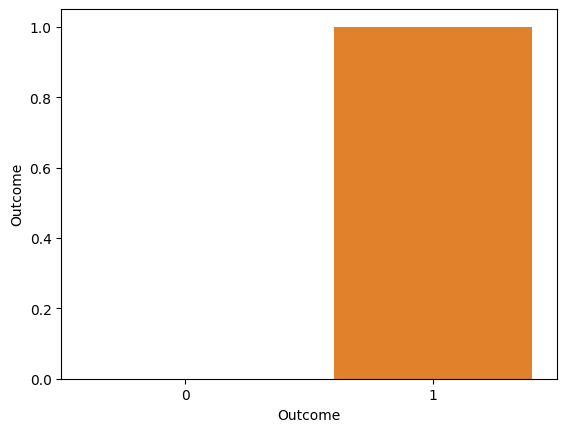

In [16]:
for col in cat_cols:
    target_summary_with_cat(df, "Outcome", col, plot=True)

# 9. Analysis of Numeric Variables by Target

In [17]:
def target_summary_with_num(dataframe, target, numerical_col, plot=False):
    print(pd.DataFrame({numerical_col+'_mean': dataframe.groupby(target)[numerical_col].mean()}), end='\n\n\n')
    if plot:
        sns.barplot(x=target, y=numerical_col, data=dataframe)
        plt.show(block=True)

         Pregnancies_mean
Outcome                  
0                   3.298
1                   4.866




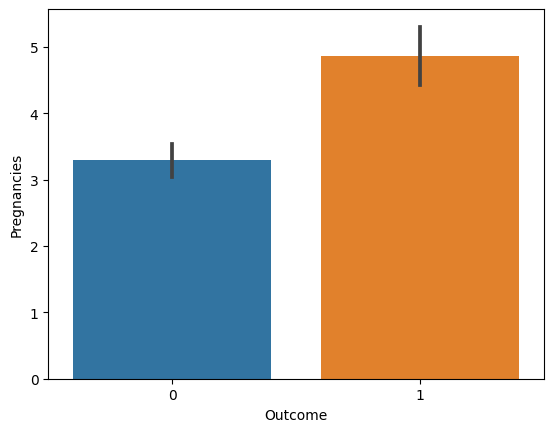

         Glucose_mean
Outcome              
0             109.980
1             141.257




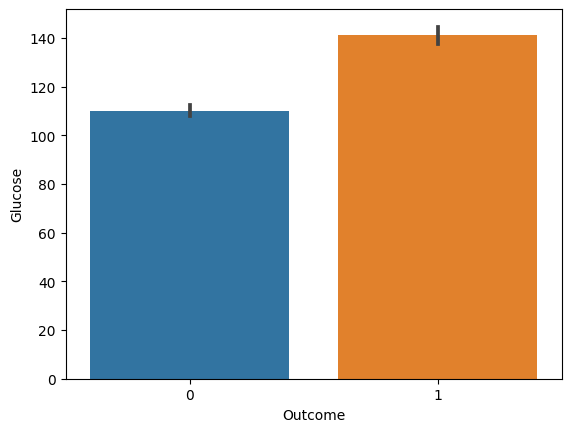

         BloodPressure_mean
Outcome                    
0                    68.184
1                    70.825




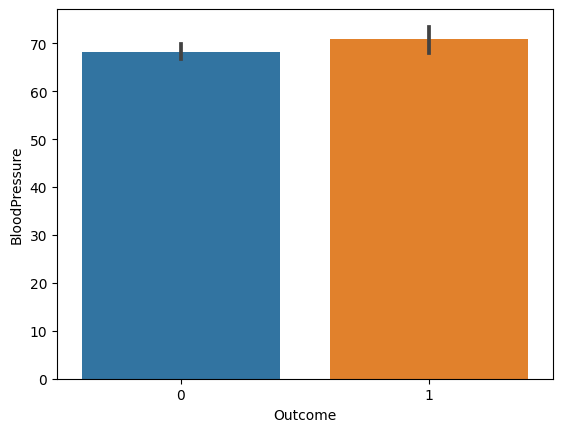

         SkinThickness_mean
Outcome                    
0                    19.664
1                    22.164




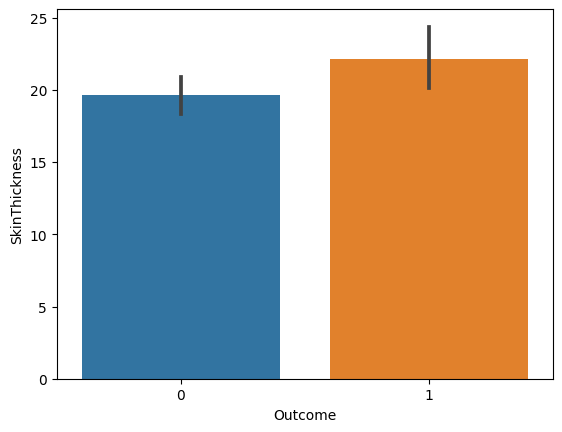

         Insulin_mean
Outcome              
0              68.792
1             100.336




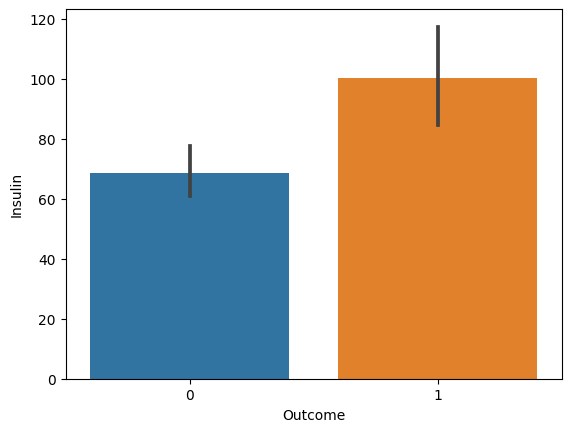

         BMI_mean
Outcome          
0          30.304
1          35.143




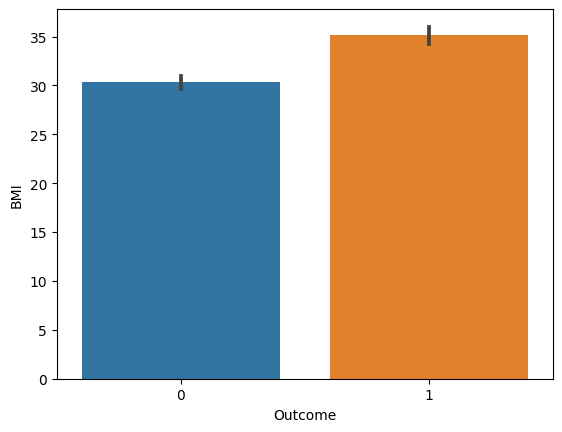

         DiabetesPedigreeFunction_mean
Outcome                               
0                                0.430
1                                0.550




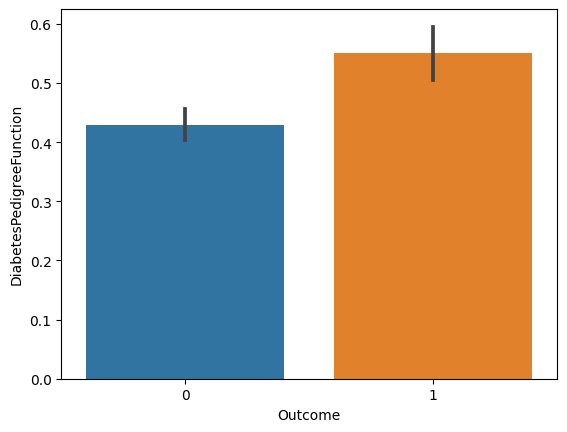

         Age_mean
Outcome          
0          31.190
1          37.067




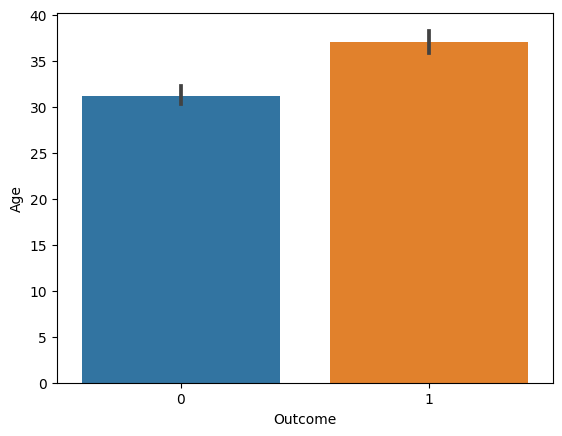

In [18]:
for col in num_cols:
    target_summary_with_num(df, "Outcome", col, plot=True)

# 10. Correlation Analysis

In [19]:
corr = df[num_cols].corr()

In [20]:
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000,0.129,0.141,-0.082,-0.074,0.018,-0.034,0.544
Glucose,0.129,1.000,0.153,0.057,0.331,0.221,0.137,0.264
BloodPressure,0.141,0.153,1.000,0.207,0.089,0.282,0.041,0.240
SkinThickness,-0.082,0.057,0.207,1.000,0.437,0.393,0.184,-0.114
Insulin,-0.074,0.331,0.089,0.437,1.000,0.198,0.185,-0.042
BMI,0.018,0.221,0.282,0.393,0.198,1.000,0.141,0.036
DiabetesPedigreeFunction,-0.034,0.137,0.041,0.184,0.185,0.141,1.000,0.034
Age,0.544,0.264,0.240,-0.114,-0.042,0.036,0.034,1.000


In [21]:
def high_correlated_cols(dataframe, plot=False, corr_th=0.70):
    corr = dataframe.corr()
    cor_matrix = corr.abs()
    upper_triangle_matrix = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))
    drop_list = [col for col in upper_triangle_matrix.columns if any(upper_triangle_matrix[col] > corr_th)]
    if plot:
        import seaborn as sns
        import matplotlib.pyplot as plt
        sns.set(rc={"figure.figsize": (8, 8)})
        corr_values = corr.round(2)
        sns.heatmap(corr, cmap="RdBu", annot=corr_values)
        plt.show(block=True)
    return drop_list

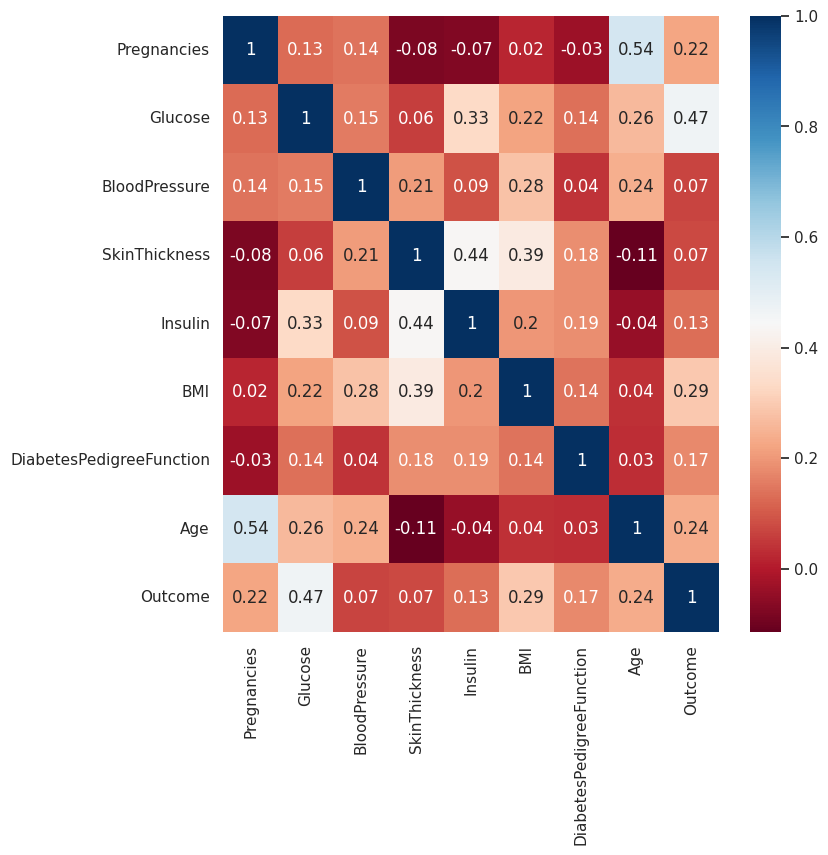

[]

In [22]:
high_correlated_cols(df, plot=True)

# 11. The Relationship Between Variables

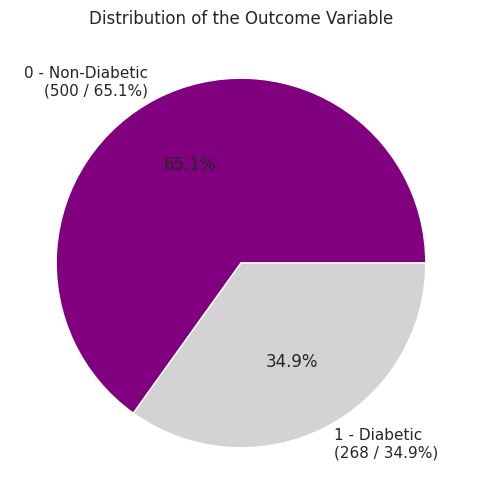

In [23]:
# Calculate the counts of each outcome
outcome_counts = df['Outcome'].value_counts()

# Calculate the total number of patients
total_patients = outcome_counts.sum()

# Calculate the percentages
percentages = outcome_counts / total_patients * 100

# Create labels with both quantity and percentage
labels = [f'0 - Non-Diabetic\n({outcome_counts[0]} / {percentages[0]:.1f}%)',
          f'1 - Diabetic\n({outcome_counts[1]} / {percentages[1]:.1f}%)']

# Plot the pie chart with labels and percentages
plt.figure(figsize=(8, 6))
plt.pie(outcome_counts, labels=labels, autopct='%1.1f%%', colors=['purple', 'lightgray'])
plt.title('Distribution of the Outcome Variable')
plt.show()

In [24]:
# Create combinations of binary categorical variables
feature_combinations = list(itertools.combinations(['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], 2))

# Create a separate Bubble Chart for each binary categorical variable
for i, (feature1, feature2) in enumerate(feature_combinations):
    fig = px.scatter(df, x=feature1, y=feature2, color='Outcome', size='BMI',
                     title=f'{feature1} vs {feature2} Bubble Chart')

    fig.show(block=True)

# 12. Outlier Analysis

In [25]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

In [26]:
def check_outlier(dataframe, col_name, plot=False):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    outliers = dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)]
    if outliers.any(axis=None):
        if plot:
            plt.figure(figsize=(8, 6))
            sns.boxplot(x=dataframe[col_name])
            plt.title(f'Outliers in {col_name}')
            plt.show()
        return True
    else:
        return False

In [27]:
def replace_with_thresholds(dataframe, variable, q1=0.05, q3=0.95):
    low_limit, up_limit = outlier_thresholds(dataframe, variable, q1=0.05, q3=0.95)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

In [28]:
for col in df.columns:
    print(col, check_outlier(df, col, plot=False))
    if check_outlier(df, col, plot=False):
        replace_with_thresholds(df, col)

Pregnancies False
Glucose False
BloodPressure False
SkinThickness False
Insulin True
BMI False
DiabetesPedigreeFunction False
Age False
Outcome False


In [29]:
for col in df.columns:
    print(col, check_outlier(df, col))

Pregnancies False
Glucose False
BloodPressure False
SkinThickness False
Insulin False
BMI False
DiabetesPedigreeFunction False
Age False
Outcome False


In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose,768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000
BloodPressure,768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000
SkinThickness,768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000
Insulin,768.000,79.637,114.243,0.000,0.000,30.500,127.250,732.500
BMI,768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


# 13. Missing Value Analysis

In [31]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [32]:
zero_colunms = [col for col in df.columns if (df[col].min() == 0 and col not in  ["Pregnancies", "Outcome"])]

In [33]:
zero_colunms

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [34]:
for col in zero_colunms:
    df[col] = np.where(df[col] == 0, np.nan, df[col])

In [35]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [36]:
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)

    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)

    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])

    print(missing_df, end="\n")

    if na_name:
        return na_columns

In [37]:
missing_values_table(df)

               n_miss  ratio
Insulin           374 48.700
SkinThickness     227 29.560
BloodPressure      35  4.560
BMI                11  1.430
Glucose             5  0.650


In [38]:
def missing_vs_target(dataframe, target, na_columns):
    temp_df = dataframe.copy()

    for col in na_columns:
        temp_df[col + '_NA_FLAG'] = np.where(temp_df[col].isnull(), 1, 0)

    na_flags = temp_df.loc[:, temp_df.columns.str.contains("_NA_")].columns

    for col in na_flags:
        print(pd.DataFrame({"TARGET_MEAN": temp_df.groupby(col)[target].mean(),
                            "Count": temp_df.groupby(col)[target].count()}), end="\n\n\n")

In [39]:
num_cols = [col for col in num_cols if col not in "Outcome"]
missing_vs_target(df, "Outcome", num_cols)

                     TARGET_MEAN  Count
Pregnancies_NA_FLAG                    
0                          0.349    768


                 TARGET_MEAN  Count
Glucose_NA_FLAG                    
0                      0.349    763
1                      0.400      5


                       TARGET_MEAN  Count
BloodPressure_NA_FLAG                    
0                            0.344    733
1                            0.457     35


                       TARGET_MEAN  Count
SkinThickness_NA_FLAG                    
0                            0.333    541
1                            0.388    227


                 TARGET_MEAN  Count
Insulin_NA_FLAG                    
0                      0.330    394
1                      0.369    374


             TARGET_MEAN  Count
BMI_NA_FLAG                    
0                  0.351    757
1                  0.182     11


                                  TARGET_MEAN  Count
DiabetesPedigreeFunction_NA_FLAG                    
0         

In [40]:
dff = pd.get_dummies(df[cat_cols + num_cols], drop_first=True)

In [41]:
scaler = RobustScaler()
dff = pd.DataFrame(scaler.fit_transform(dff), columns=dff.columns)

In [42]:
imputer = KNNImputer(n_neighbors=5)
dff = pd.DataFrame(imputer.fit_transform(dff), columns=dff.columns)

In [43]:
dff = pd.DataFrame(scaler.inverse_transform(dff), columns=dff.columns)

In [44]:
df[num_cols] = dff[num_cols]

In [45]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [46]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.000,148.000,72.000,35.000,400.200,33.600,0.627,50.000,1
1,1.000,85.000,66.000,29.000,65.200,26.600,0.351,31.000,0
2,8.000,183.000,64.000,28.000,194.600,23.300,0.672,32.000,1
3,1.000,89.000,66.000,23.000,94.000,28.100,0.167,21.000,0
4,0.000,137.000,40.000,35.000,168.000,43.100,2.288,33.000,1


# 14. Feature Extraction

In [47]:
df[(df["BMI"] > 30) & (df["DiabetesPedigreeFunction"] > 0.3) & (df["Age"] > 35)].head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.000,148.000,72.000,35.000,400.200,33.600,0.627,50.000,1
13,1.000,189.000,60.000,23.000,732.500,30.100,0.398,59.000,1
21,8.000,99.000,84.000,33.800,112.400,35.400,0.388,50.000,0
22,7.000,196.000,90.000,32.600,245.000,39.800,0.451,41.000,1
29,5.000,117.000,92.000,26.200,129.000,34.100,0.337,38.000,0
30,5.000,109.000,75.000,26.000,142.200,36.000,0.546,60.000,0
37,9.000,102.000,76.000,37.000,244.600,32.900,0.665,46.000,1
39,4.000,111.000,72.000,47.000,207.000,37.100,1.390,56.000,1
41,7.000,133.000,84.000,36.000,261.000,40.200,0.696,37.000,0
43,9.000,171.000,110.000,24.000,240.000,45.400,0.721,54.000,1


In [48]:
print(df[(df["Glucose"] > 130) & (df["Insulin"] > 120)].shape)
df[(df["Glucose"] > 130) & (df["Insulin"] > 120) & (df["Outcome"] == 1)].shape

(228, 9)


(151, 9)

In [49]:
print(df[(df["Age"] > 40) & (df["DiabetesPedigreeFunction"] > 0.6)].shape)
df[(df["Age"] > 40) & (df["DiabetesPedigreeFunction"] > 0.6) & (df["Outcome"] == 1)].shape

(54, 9)


(33, 9)

In [50]:
df["Insulin"].max()

732.5

In [51]:
print(df[(df["Insulin"] > 180) & (df["Age"] > 30) & (df["DiabetesPedigreeFunction"] > 0.5)].shape)
df[(df["Insulin"] > 180) & (df["Age"] > 30) & (df["DiabetesPedigreeFunction"] > 0.5) & (df["Outcome"] == 1)].shape

(61, 9)


(41, 9)

In [52]:
df[(df["Glucose"] > 150) & (df["Outcome"] == 0)].shape

(35, 9)

In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose,768.000,121.659,30.515,44.000,99.000,117.000,141.000,199.000
BloodPressure,768.000,72.311,12.185,24.000,64.000,72.000,80.000,122.000
SkinThickness,768.000,29.070,9.470,7.000,23.000,29.000,35.000,99.000
Insulin,768.000,152.976,96.133,14.000,88.000,130.000,191.500,732.500
BMI,768.000,32.416,6.890,18.200,27.500,32.050,36.600,67.100
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


In [54]:
df['Age_Segment'] = pd.cut(df['Age'], bins=[0, 25, 35, 50, 100],
                         labels=[1, 2, 3, 4], right=False)

df['Glucose_Segment'] = pd.cut(df['Glucose'], bins=[0, 80, 130, 200],
                         labels=[2, 3, 5], right=False)

df['BloodPressure_Segment'] = pd.cut(df['BloodPressure'], bins=[20, 70, 100, 125],
                         labels=[1, 2, 3], right=False)

df['Insulin_Segment'] = pd.cut(df['Insulin'], bins=[0, 90, 130, 200, 750],
                         labels=[1, 2, 3, 4], right=False)

df['BMI_Segment'] = pd.cut(df['BMI'], bins=[15, 30, 35, 50, 70],
                         labels=[1, 2, 3, 4], right=False)

In [55]:
df['Pregnancies_Segment'] = pd.qcut(df['Pregnancies'], q=4, labels=[1, 2, 3, 4])
df['DPF_Segment'] = pd.qcut(df['DiabetesPedigreeFunction'], q=4, labels=[1, 2, 3, 4])
df['SkinThickness_Segment'] = pd.qcut(df['SkinThickness'], q=4, labels=[1, 2, 3, 4])

In [56]:
cat_cols, num_cols, cat_but_car,  num_but_cat = grab_col_names(df)

Observations: 768
Variables: 17
cat_cols: 9
num_cols: 8
cat_but_car: 0
num_but_cat: 9


In [57]:
cat_cols

['Outcome',
 'Age_Segment',
 'Glucose_Segment',
 'BloodPressure_Segment',
 'Insulin_Segment',
 'BMI_Segment',
 'Pregnancies_Segment',
 'DPF_Segment',
 'SkinThickness_Segment']

In [58]:
num_cols = ['Age_Segment',
 'Glucose_Segment',
 'BloodPressure_Segment',
 'Insulin_Segment',
 'BMI_Segment',
 'Pregnancies_Segment',
 'DPF_Segment',
 'SkinThickness_Segment',
 'Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [59]:
for col in num_cols:
    df[col] = df[col].astype(int)

In [60]:
# yaş büyük ve glikoz yüksekse 1 40 yaş üzeri
# yaş büyük tansiyon 110 dan yüksekse 1
# glikoz yüksek insulin düşükse 
# en az bir hamile ve glikoz yüksekse
# Deri kalınlığı ve tansiyon yüksekse
# Deri kalınlığı yüksek insulin düşükse 
# yaş ve insulin yüksekse 
# ailesel yatkınlık yüksek ve 45 yaş üzeri ise
# glikoz 150 üzeri olanlar !
# yaş yüksek insulin yüksek genetik yüksek

In [61]:
# HbA1c

df["HbA1c"] = (df["Glucose"] + 46.7) / 28.7

In [62]:
df["risk_group1"] = df['Age_Segment'] * df['Glucose_Segment']
df["risk_group2"] = df['Age_Segment'] * df['BloodPressure_Segment']
df["risk_group3"] = df['Age_Segment'] * df['Insulin_Segment']
df["risk_group4"] = df['Age_Segment'] + df['Insulin_Segment'] * df['Glucose_Segment']
df["risk_group5"] = df['Age_Segment'] + df['Insulin_Segment'] * df['DPF_Segment']
df['G/I_Segment'] = df['Glucose_Segment'] / df['Insulin_Segment']
df['G/I_Segment2'] = df['Glucose_Segment'] - df['Insulin_Segment']
df['Skin_Blood_Segment'] = df['SkinThickness_Segment'] * df['BloodPressure_Segment']
df['Skin_Blood_Segment2'] = df['SkinThickness_Segment'] - df['Insulin_Segment']

In [63]:
df.loc[(df["Glucose"] >= 130) & (df["Insulin"] >= 120), "Gli_Ins"] = "High_Risk"
df.loc[(df["Glucose"] < 130) & (df["Insulin"] < 120), "Gli_Ins"] = "Risk"
df["Gli_Ins"].fillna("Normal", inplace=True)

df.loc[(df["Age"] >= 40) & (df["DiabetesPedigreeFunction"] >= 0.6), "Age_Pedigree"] = "High_Risk"
df.loc[(df["Age"] < 40) & (df["DiabetesPedigreeFunction"] < 0.6), "Age_Pedigree"] = "Risk"
df["Age_Pedigree"].fillna("Normal", inplace=True)

df.loc[(df["Insulin"] >= 180) & (df["Age"] >= 30), "Age_Ins"] = "High_Risk"
df.loc[(df["Insulin"] < 180) & (df["Age"] < 30), "Age_Ins"] = "Risk"
df["Age_Ins"].fillna("Normal", inplace=True)

# 15. Encoding

In [64]:
cat_cols, num_cols, cat_but_car,  num_but_cat = grab_col_names(df)

Observations: 768
Variables: 30
cat_cols: 18
num_cols: 12
cat_but_car: 0
num_but_cat: 15


In [65]:
num_cols

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'Age',
 'HbA1c',
 'risk_group1',
 'risk_group4',
 'risk_group5',
 'G/I_Segment']

In [66]:
cat_cols = ['Gli_Ins',
 'Age_Pedigree',
 'Age_Ins',
 'Outcome']

In [67]:
num_cols = ['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'Age',
 'HbA1c',
 'risk_group1',
 'risk_group4',
 'risk_group5',
 'G/I_Segment',
 'DiabetesPedigreeFunction',
 'Age_Segment',
 'Glucose_Segment',
 'BloodPressure_Segment',
 'Insulin_Segment',
 'BMI_Segment',
 'Pregnancies_Segment',
 'DPF_Segment',
 'SkinThickness_Segment',
 'risk_group2',
 'risk_group3',
 'G/I_Segment2',
 'Skin_Blood_Segment',
 'Skin_Blood_Segment2']

In [68]:
# Label Encoding

def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

In [69]:
binary_cols = [col for col in df.columns if df[col].dtypes == "O" and df[col].nunique() == 2]

In [70]:
binary_cols

[]

In [71]:
# One-Hot Encoding

cat_cols = [col for col in cat_cols if col not in binary_cols and col not in ["Outcome"]]

In [72]:
cat_cols

['Gli_Ins', 'Age_Pedigree', 'Age_Ins']

In [73]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=False):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

In [74]:
df = one_hot_encoder(df, cat_cols, drop_first=True)

In [75]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Segment,Glucose_Segment,BloodPressure_Segment,Insulin_Segment,BMI_Segment,Pregnancies_Segment,DPF_Segment,SkinThickness_Segment,HbA1c,risk_group1,risk_group2,risk_group3,risk_group4,risk_group5,G/I_Segment,G/I_Segment2,Skin_Blood_Segment,Skin_Blood_Segment2,Gli_Ins_Normal,Gli_Ins_Risk,Age_Pedigree_Normal,Age_Pedigree_Risk,Age_Ins_Normal,Age_Ins_Risk
0,6,148,72,35,400,33,0,50,1,4,5,2,4,2,3,4,3,6.784,20,8,16,24,20,1.250,1,6,-1,False,False,True,False,False,False
1,1,85,66,29,65,26,0,31,0,2,3,1,1,1,1,2,2,4.589,6,2,2,5,4,3.000,2,2,1,False,True,False,True,True,False
2,8,183,64,28,194,23,0,32,1,2,5,1,3,1,4,4,2,8.003,10,2,6,17,14,1.667,2,2,-1,False,False,False,True,False,False
3,1,89,66,23,94,28,0,21,0,1,3,1,2,1,1,1,1,4.728,3,1,2,7,3,1.500,1,1,-1,False,True,False,True,False,True
4,0,137,40,35,168,43,2,33,1,2,5,1,3,3,1,4,3,6.401,10,2,6,17,14,1.667,2,3,0,False,False,True,False,True,False


# 16. Standardization Process

In [76]:
num_cols

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'Age',
 'HbA1c',
 'risk_group1',
 'risk_group4',
 'risk_group5',
 'G/I_Segment',
 'DiabetesPedigreeFunction',
 'Age_Segment',
 'Glucose_Segment',
 'BloodPressure_Segment',
 'Insulin_Segment',
 'BMI_Segment',
 'Pregnancies_Segment',
 'DPF_Segment',
 'SkinThickness_Segment',
 'risk_group2',
 'risk_group3',
 'G/I_Segment2',
 'Skin_Blood_Segment',
 'Skin_Blood_Segment2']

In [77]:
scaler = RobustScaler()

In [78]:
df[num_cols] = scaler.fit_transform(df[num_cols])

In [79]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_Segment,Glucose_Segment,BloodPressure_Segment,Insulin_Segment,BMI_Segment,Pregnancies_Segment,DPF_Segment,SkinThickness_Segment,HbA1c,risk_group1,risk_group2,risk_group3,risk_group4,risk_group5,G/I_Segment,G/I_Segment2,Skin_Blood_Segment,Skin_Blood_Segment2,Gli_Ins_Normal,Gli_Ins_Risk,Age_Pedigree_Normal,Age_Pedigree_Risk,Age_Ins_Normal,Age_Ins_Risk
0,0.600,0.738,0.000,0.500,2.621,0.111,0.000,1.235,1,1.000,1.000,0.000,0.500,0.000,0.500,1.000,0.500,0.738,2.800,1.000,2.000,1.300,2.167,-0.333,0.000,0.500,-0.500,False,False,True,False,False,False
1,-0.400,-0.762,-0.375,0.000,-0.631,-0.667,0.000,0.118,0,0.000,0.000,-1.000,-1.000,-0.500,-0.500,-0.333,0.000,-0.762,0.000,-0.500,-0.333,-0.600,-0.500,2.000,1.000,-0.500,0.500,False,True,False,True,True,False
2,1.000,1.571,-0.500,-0.083,0.621,-1.000,0.000,0.176,1,0.000,1.000,-1.000,0.000,-0.500,1.000,1.000,0.000,1.571,0.800,-0.500,0.333,0.600,1.167,0.222,1.000,-0.500,-0.500,False,False,False,True,False,False
3,-0.400,-0.667,-0.375,-0.500,-0.350,-0.444,0.000,-0.471,0,-0.500,0.000,-1.000,-0.500,-0.500,-0.500,-1.000,-0.500,-0.667,-0.600,-0.750,-0.333,-0.400,-0.667,0.000,0.000,-0.750,-0.500,False,True,False,True,False,True
4,-0.600,0.476,-2.000,0.500,0.369,1.222,2.000,0.235,1,0.000,1.000,-1.000,0.000,0.500,-0.500,1.000,0.500,0.476,0.800,-0.500,0.333,0.600,1.167,0.222,1.000,-0.250,0.000,False,False,True,False,True,False


# 17. Creating Model

In [80]:
# Creating the Dependent Variable.

y = df["Outcome"]

# Creating Independent Variables.

X = df.drop("Outcome", axis=1)

# Splitting the Data into Training and Test Sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)

In [81]:
# Defining the models
models = [
    ('LR', LogisticRegression(random_state=12345)),
    ('KNN', KNeighborsClassifier()),
    ('CART', DecisionTreeClassifier(random_state=12345)),
    ('RF', RandomForestClassifier(random_state=12345)),
    ('XGB', XGBClassifier(random_state=12345)),
    ("CatBoost", CatBoostClassifier(verbose=False, random_state=12345))
]

# Create an empty list to store metrics
last_models_metrics = []

# Loop through each model to evaluate using cross-validation
for name, model in models:
    # Perform cross-validation
    cv_results = cross_validate(model, X_train, y_train, cv=5, scoring=["accuracy", "f1", "roc_auc", "precision", "recall"])

    # Calculate the mean of each metric
    accuracy = round(cv_results['test_accuracy'].mean(), 4)
    auc = round(cv_results['test_roc_auc'].mean(), 4)
    recall = round(cv_results['test_recall'].mean(), 4)
    precision = round(cv_results['test_precision'].mean(), 4)
    f1 = round(cv_results['test_f1'].mean(), 4)

    # Append the results to the list
    last_models_metrics.append({
        "Model": name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Recall": recall,
        "Precision": precision,
        "F1": f1
    })

    # Print the model's performance metrics
    print(f"########## {name} ##########")
    print(f"Accuracy: {accuracy}")
    print(f"AUC: {auc}")
    print(f"Recall: {recall}")
    print(f"Precision: {precision}")
    print(f"F1: {f1}")

# Optionally, convert the results into a DataFrame for better visualization
import pandas as pd
metrics_df = pd.DataFrame(last_models_metrics)
print(metrics_df)


########## LR ##########
Accuracy: 0.7804
AUC: 0.8535
Recall: 0.6376
Precision: 0.7064
F1: 0.6646
########## KNN ##########
Accuracy: 0.7263
AUC: 0.7917
Recall: 0.5836
Precision: 0.6155
F1: 0.5968
########## CART ##########
Accuracy: 0.6947
AUC: 0.6668
Recall: 0.5737
Precision: 0.5619
F1: 0.5601
########## RF ##########
Accuracy: 0.7655
AUC: 0.8317
Recall: 0.6162
Precision: 0.6835
F1: 0.6427
########## XGB ##########
Accuracy: 0.7599
AUC: 0.8111
Recall: 0.6319
Precision: 0.6707
F1: 0.6417
########## CatBoost ##########
Accuracy: 0.7692
AUC: 0.8448
Recall: 0.6482
Precision: 0.6797
F1: 0.6589
      Model  Accuracy   AUC  Recall  Precision    F1
0        LR     0.780 0.854   0.638      0.706 0.665
1       KNN     0.726 0.792   0.584      0.616 0.597
2      CART     0.695 0.667   0.574      0.562 0.560
3        RF     0.765 0.832   0.616      0.683 0.643
4       XGB     0.760 0.811   0.632      0.671 0.642
5  CatBoost     0.769 0.845   0.648      0.680 0.659


# 18. Feature Importance

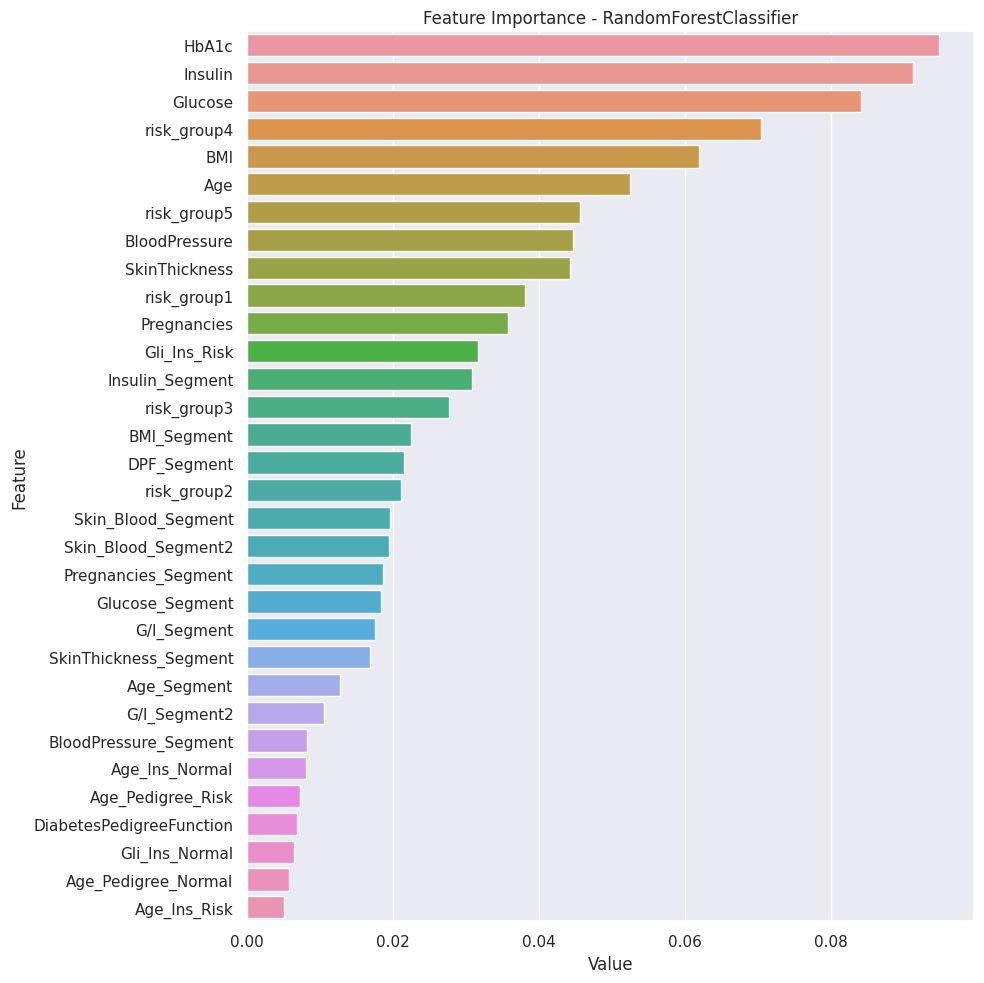

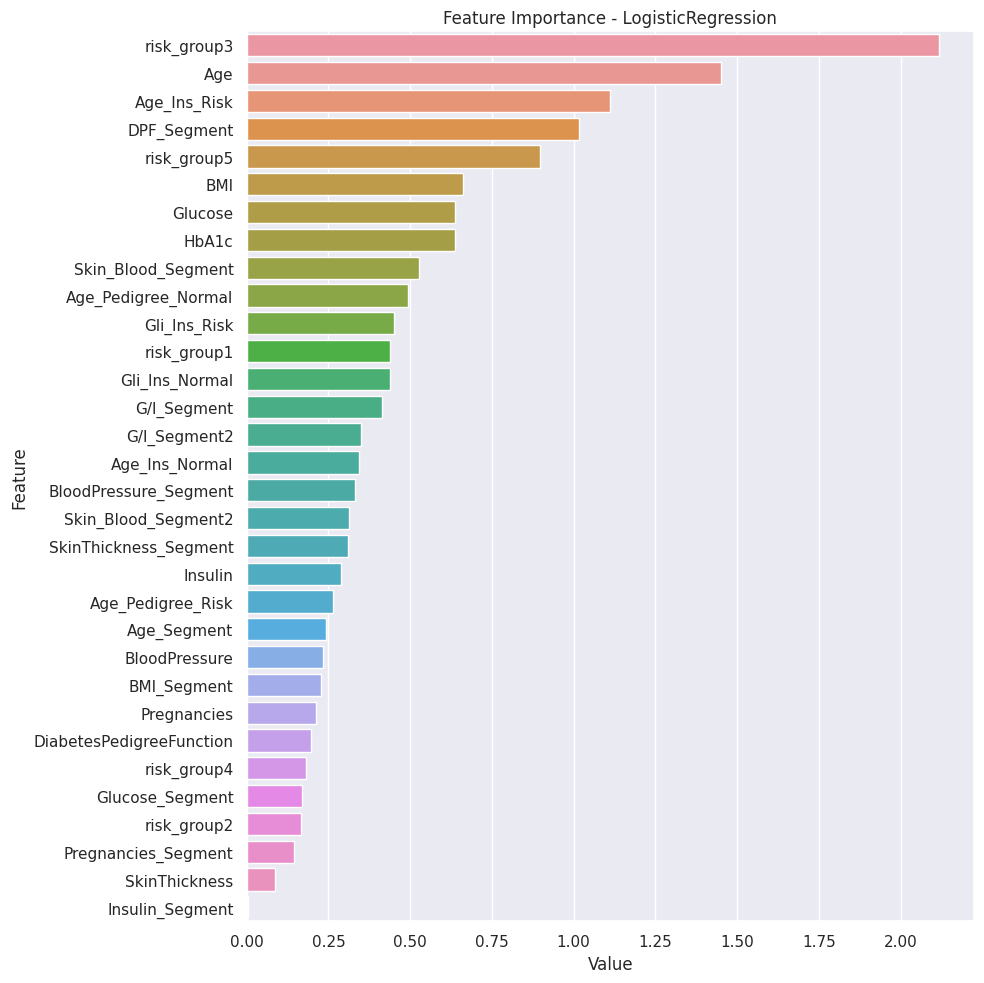

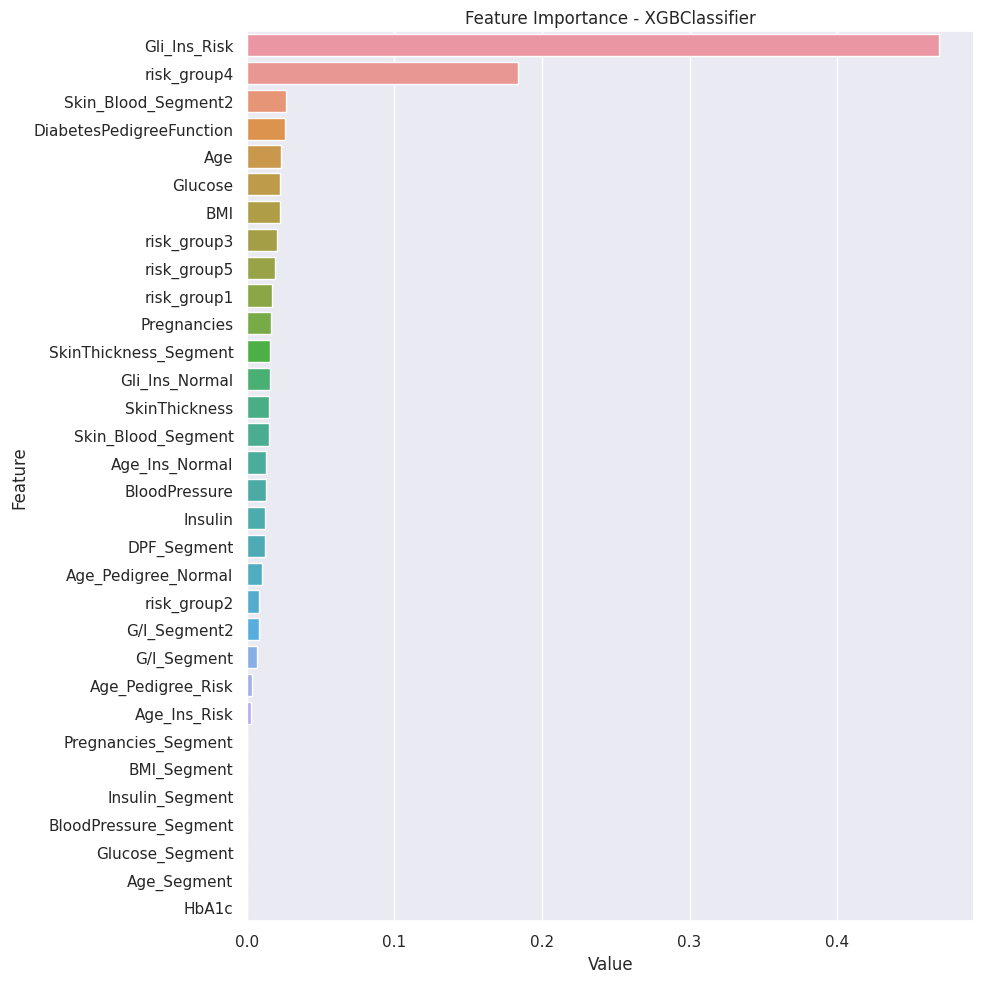

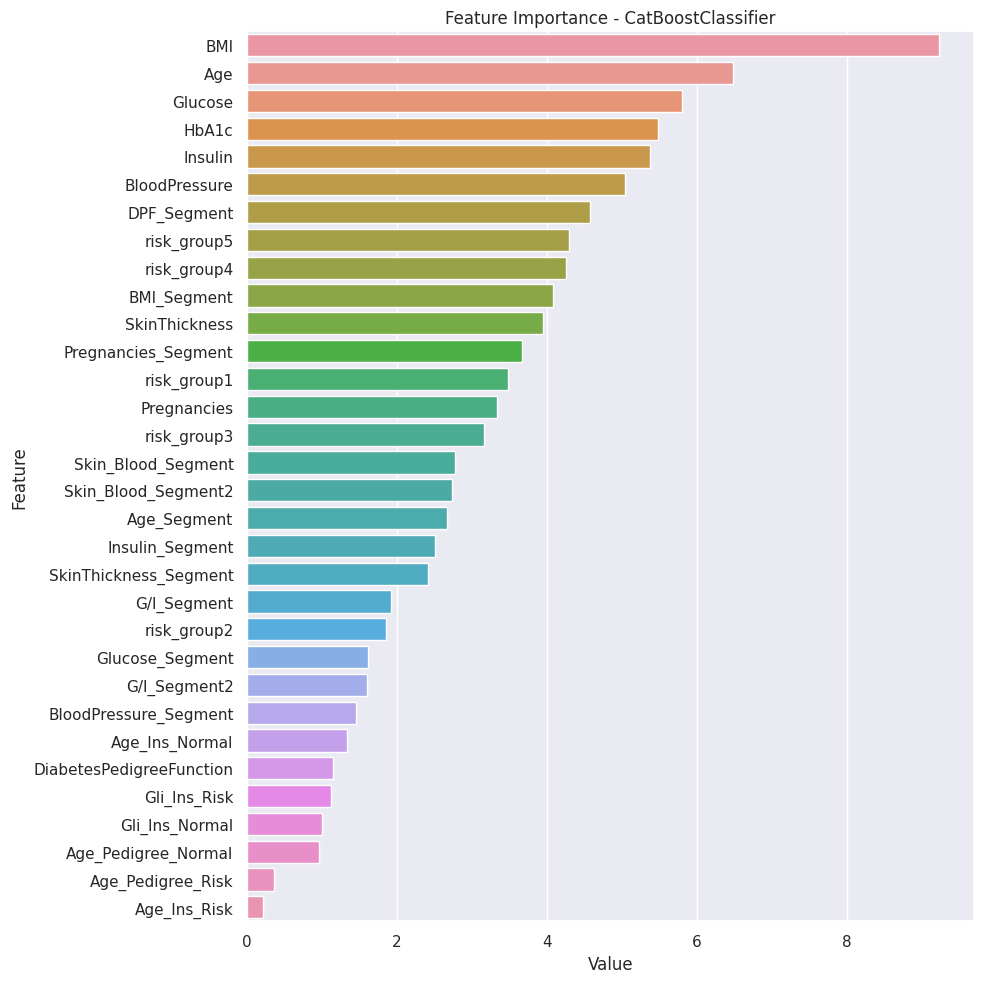

In [82]:
def plot_importance(model, features, num=None, save=False):
    # Plotlanacak özellik sayısını varsayılan olarak sütun sayısı olarak ayarla
    if num is None:
        num = len(features.columns)

    # Modelin feature importance özelliğini kontrol et
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        # LogisticRegression gibi modeller için
        importances = model.coef_[0] if model.coef_.ndim == 2 else model.coef_
        importances = np.abs(importances)
    else:
        print(f"{model.__class__.__name__} modelinde özellik önem değerleri bulunamadı.")
        return

    feature_imp = pd.DataFrame({'Value': importances, 'Feature': features.columns})

    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature",
                data=feature_imp.sort_values(by="Value", ascending=False).iloc[:num])
    plt.title(f'Feature Importance - {model.__class__.__name__}')
    plt.tight_layout()
    if save:
        plt.savefig(f'importances_{model.__class__.__name__}.png')
    plt.show()

# Örnek kullanım:
models = [RandomForestClassifier(),
          LogisticRegression(),
          XGBClassifier(),
          # LGBMClassifier(),
          CatBoostClassifier(verbose=False, random_state=12345)
         ]

for model in models:
    model.fit(X, y)
    plot_importance(model, X)

# 19. Hyperparameter Optimization

In [83]:
# Data Split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    stratify=y, 
    random_state=12345
)

# Hyperparameter grids
param_grids = {
    "LR": {"C": [0.001, 0.01, 0.1, 1, 10, 100]},
    "KNN": {"n_neighbors": [3, 5, 7, 9], "weights": ['uniform', 'distance']},
    "CART": {"max_depth": [3, 5, 7, None], "min_samples_split": [2, 5, 10]},
    "RF": {"n_estimators": [100, 200], "max_depth": [5, 7, None], "min_samples_leaf": [1, 2]},
    "XGB": {"learning_rate": [0.01, 0.1], "max_depth": [3, 5], "subsample": [0.8, 1.0]},
    "LightGBM": {"num_leaves": [31, 63], "learning_rate": [0.01, 0.1], "n_estimators": [100, 200]},
    "CatBoost": {"iterations": [500], "depth": [4, 6], "learning_rate": [0.03, 0.1]}
}

# Optimization
def optimize_and_evaluate(models, param_grids):
    optimized_results = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=12345)
    
    for model_info in models:
        name = model_info[0]
        model = model_info[1]
        
        print(f"\n⏳ {name} Optimization...")
        
        try:
            if name not in param_grids:
                raise ValueError(f"{name} no parametre grid")
                
            gs = GridSearchCV(
                estimator=model,
                param_grid=param_grids[name],
                cv=skf,
                scoring='accuracy',
                n_jobs=-1,
                verbose=0
            ).fit(X_train, y_train)
            
            final_model = gs.best_estimator_
            y_pred = final_model.predict(X_test)
            y_proba = final_model.predict_proba(X_test)[:,1] if hasattr(final_model, "predict_proba") else None
            
            metrics = {
                "Model": name,
                "Best Params": gs.best_params_,
                "Test Accuracy": round(accuracy_score(y_test, y_pred), 4),
                "Test AUC": round(roc_auc_score(y_test, y_proba), 4) if y_proba is not None else "N/A",
                "Test F1": round(f1_score(y_test, y_pred), 4),
                "Test Precision": round(precision_score(y_test, y_pred), 4),
                "Test Recall": round(recall_score(y_test, y_pred), 4)
            }
            
            optimized_results.append(metrics)
            print(f"✅ {name} completed | Best accuracy: {metrics['Test Accuracy']}")
            
        except Exception as e:
            print(f"❌ {name} error: {str(e)}")
            continue
    
    return pd.DataFrame(optimized_results)

param_grids = {
    "LR": {"C": [0.001, 0.01, 0.1, 1, 10, 100]},
    "KNN": {"n_neighbors": [3, 5, 7, 9], "weights": ['uniform', 'distance']},
    "CART": {"max_depth": [3, 5, 7, None], "min_samples_split": [2, 5, 10]},
    "RF": {"n_estimators": [100, 200], "max_depth": [5, 7, None], "min_samples_leaf": [1, 2]},
    "XGB": {"learning_rate": [0.01, 0.1], "max_depth": [3, 5], "subsample": [0.8, 1.0]},
    # "LightGBM": {"num_leaves": [31, 63], "learning_rate": [0.01, 0.1], "n_estimators": [100, 200]},
    "CatBoost": {"iterations": [500], "depth": [4, 6], "learning_rate": [0.03, 0.1]}
}

# Model list (original)
models_to_optimize = [
    ("LR", LogisticRegression(random_state=12345, max_iter=1000)),
    ("KNN", KNeighborsClassifier()),
    ("CART", DecisionTreeClassifier(random_state=12345)),
    ("RF", RandomForestClassifier(random_state=12345, n_jobs=-1)),
    ("XGB", XGBClassifier(random_state=12345, n_jobs=-1)),
    # ("LightGBM", LGBMClassifier(random_state=12345, verbose=-1, n_jobs=-1)), 
    ("CatBoost", CatBoostClassifier(random_state=12345, verbose=False))
]

optimized_df = optimize_and_evaluate(
    models=models_to_optimize,
    param_grids=param_grids
)


⏳ LR Optimization...
✅ LR completed | Best accuracy: 0.7792

⏳ KNN Optimization...
✅ KNN completed | Best accuracy: 0.7403

⏳ CART Optimization...
✅ CART completed | Best accuracy: 0.7338

⏳ RF Optimization...
✅ RF completed | Best accuracy: 0.8117

⏳ XGB Optimization...
✅ XGB completed | Best accuracy: 0.8052

⏳ CatBoost Optimization...
✅ CatBoost completed | Best accuracy: 0.8377


# 20. Final Model

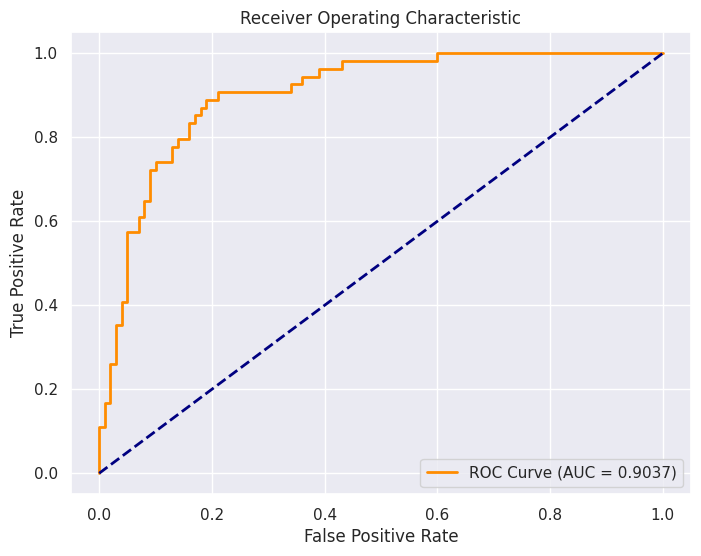

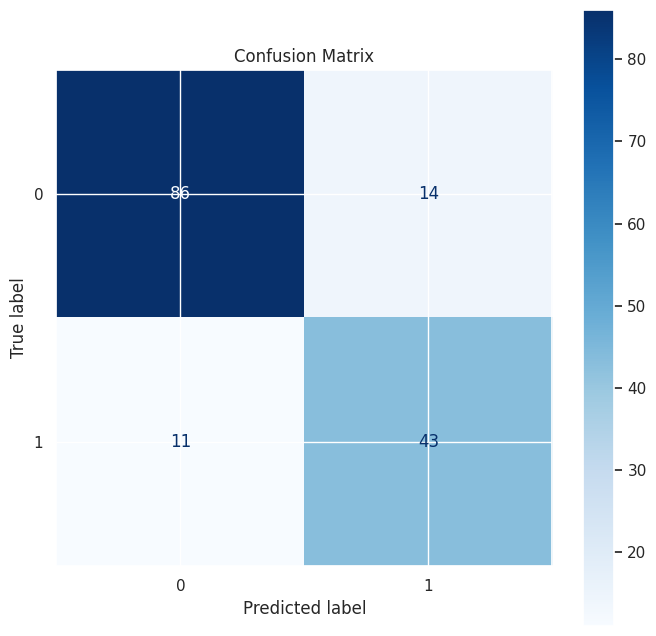

Final Model Performance on Test Set
-------------------------------------
Accuracy : 0.8377
Recall   : 0.7963
Precision: 0.7544
F1 Score : 0.7748
AUC      : 0.9037


In [84]:
# Identify the best model based on Test Accuracy
best_row = optimized_df.loc[optimized_df['Test Accuracy'].idxmax()]
model_name = best_row['Model']
best_params = best_row['Best Params']

# Find the corresponding base model from models_to_optimize
base_model = None
for name, model in models_to_optimize:
    if name == model_name:
        base_model = model
        break
if base_model is None:
    raise ValueError(f"Model {model_name} not found in models_to_optimize")

# Clone the base model and set the best parameters
from sklearn.base import clone
best_model = clone(base_model)
best_model.set_params(**best_params)

# Train the best model on the entire training data
best_model.fit(X_train, y_train)

# Test set predictions
y_final_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # Positive class probabilities

# ROC Curve calculations
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Performance metrics
accuracy = accuracy_score(y_test, y_final_pred)
recall = recall_score(y_test, y_final_pred)
precision = precision_score(y_test, y_final_pred)
f1 = f1_score(y_test, y_final_pred)
auc_score = roc_auc_score(y_test, y_proba)

print("Final Model Performance on Test Set")
print("-------------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc_score:.4f}")